In [38]:
#Load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
import keras_tuner
from tensorflow.keras import layers,Model,Sequential
from sklearn.preprocessing import StandardScaler

In [39]:
#Load the cleaned data
data = pd.read_csv('final_data.csv')
print(len(data))
data.columns

9380


Index(['Unnamed: 0', 'name', 'SID', 'timestamp', 'visitors', 'avgDuration',
       'weekday', 'hour_sin', 'hour_cos'],
      dtype='str')

In [40]:
#Configurations

features = ['visitors','avgDuration','weekday','hour_sin','hour_cos']
n_features = len(features)
window_size = 24

In [41]:
data = data.sort_values(['SID','timestamp'])
data.head()

,Unnamed: 0,name,SID,timestamp,visitors,avgDuration,weekday,hour_sin,hour_cos
0,0,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 01:00:00+00:00,1.0,17.5500,0,0.258819,0.965926
1,1,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 02:00:00+00:00,3.0,4.1000,0,0.500000,0.866025
2,2,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 03:00:00+00:00,3.0,0.7500,0,0.707107,0.707107
3,3,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 04:00:00+00:00,17.0,6.2075,0,0.866025,0.500000
4,4,Kurpark - Eingang Kurhaus,26213d2d-2954-4312-b42a-a6b323764086,2025-06-30 05:00:00+00:00,28.0,5.1475,0,0.965926,0.258819


In [44]:
train_data = []
sensor_ids = []
window_times = []
location = []

for sensor in data['SID'].unique():

    sensor_data = data[data['SID'] == sensor]

    values = sensor_data[features].values
    timestamps = sensor_data["timestamp"].values
    name = sensor_data['name'].values

    for i in range(len(values) - window_size + 1):
        train_data.append(values[i:i+window_size])
        sensor_ids.append(sensor)
        window_times.append(timestamps[i + window_size - 1]) #Append the last time
        location.append(name[i + window_size - 1])

train_data = np.array(train_data)
print(train_data.shape)

(8736, 24, 5)


In [45]:
#Standardarizing the data

scaler = StandardScaler()
train_data_reshaped = train_data.reshape(-1,2)
train_data_scaled = scaler.fit_transform(train_data_reshaped)

#Convert our data into normal shape
train_data = train_data_scaled.reshape(-1,24,n_features)
print(train_data.shape)

(8736, 24, 5)


In [46]:
#Plot the loss functions

def loss_function_analysis(history):
    history_dict = history.history
    train_loss = history_dict['loss']
    validation_loss = history_dict['val_loss']
    epoches = [i for i in range(1,len(train_loss)+1)]
    plt.plot(epoches,train_loss,label='Train Loss',color = 'black')
    plt.plot(epoches,validation_loss,label = 'Validation Loss', color = 'red')
    plt.xlabel('Epoches')
    plt.ylabel('Loss')
    plt.title('Loss Function Analysis')
    plt.legend()
    plt.show()

In [47]:
#Build a Autoencoder-LSTM Model

inputs = layers.Input(shape=(window_size,n_features))
x = layers.LSTM(64,return_sequences=True)(inputs)
x = layers.LSTM(32,return_sequences = False)(x)

#Then it is a bottleneck or a latent which saves the compressed knowledge
latent = layers.Dense(16,activation='relu')(x)

x = layers.RepeatVector(window_size)(latent)
x = layers.LSTM(32,return_sequences = True)(x)
x = layers.LSTM(64,return_sequences=True)(x)

outputs = layers.TimeDistributed(layers.Dense(n_features))(x)

model = Model(inputs,outputs)

In [30]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 24, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 24, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 24, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,293 (243.33 KB)

 Trainable params: 62,293 (243.33 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(optimizer = 'adam',loss= 'mse')

In [61]:
#ran until 30 , generalization decreases. starts to remember. so reduced to 25

history = model.fit(train_data,train_data,
          epochs =25 ,
          batch_size=64,
         validation_split=0.2)

Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0679 - val_loss: 0.0569
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0622 - val_loss: 0.0569
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0616 - val_loss: 0.0679
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0673 - val_loss: 0.0583
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0643 - val_loss: 0.0673
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0606 - val_loss: 0.0575
Epoch 7/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0612 - val_loss: 0.0576
Epoch 8/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0595 - val_loss: 0.0549
Epoch 9/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0570 - val_loss: 0.0566
Epoch 10/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0582 - val_loss: 0.0537
Epoch 11/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0666 - val_loss: 0.0586
Epoch 12/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 

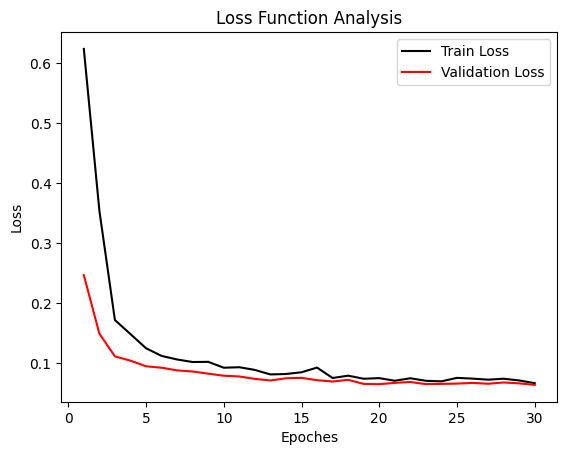

In [12]:
loss_function_analysis(history)

In [50]:
pred = model.predict(train_data)

273/273 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [51]:
errors = np.mean(np.square(train_data-pred),axis = (1,2))

In [52]:
errors

array([0.02087143, 0.02100594, 0.02273681, ..., 0.07282412, 0.06608625,
       0.06669076], shape=(8736,))

In [53]:
results = pd.DataFrame({
    "SID": sensor_ids,
    "location": location,
    "timestamp": window_times,
    "error": errors
})

In [54]:
results

,SID,location,timestamp,error
0,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-07-01 00:00:00+00:00,0.020871
1,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-07-01 01:00:00+00:00,0.021006
2,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-07-01 02:00:00+00:00,0.022737
3,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-07-01 03:00:00+00:00,0.021850
4,26213d2d-2954-4312-b42a-a6b323764086,Kurpark - Eingang Kurhaus,2025-07-01 04:00:00+00:00,0.023183
...,...,...,...,...
8731,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 19:00:00+00:00,0.077913
8732,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 20:00:00+00:00,0.078133
8733,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 21:00:00+00:00,0.072824
8734,fdf97c35-96ee-44ef-8d7f-f8c48f9b4eb8,Parkstraße 24,2025-07-13 22:00:00+00:00,0.066086


In [55]:
sensors = list(results['SID'].unique())

In [56]:
#Determine the reconstruction error distribution for each sensor

def anomaly_plot(sensor_id):
    sensor_data = results[results['SID'] == sensor_id]
    sensor_data['timestamp'] = pd.to_datetime(sensor_data['timestamp'])
    sensor_data = sensor_data.sort_values('timestamp')
    location = sensor_data['location'].iloc[0]
    agg = sensor_data.groupby('timestamp', as_index=False)['error'].mean()
    threshold = np.percentile(agg['error'], 95)
    plt.clf()
    plt.plot(agg['timestamp'], agg['error'], label='error')
    plt.axhline(threshold, color='red', linestyle='--', label= f'Threshold: {threshold}')
    anomalies = agg[agg['error'] > threshold]
    plt.scatter(anomalies['timestamp'], anomalies['error'], color='red', s=10, label='anomaly')
    plt.xlabel('Date')
    plt.ylabel('Reconstruction Errors')
    plt.title(f'Anomaly on Sensor at {location}')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

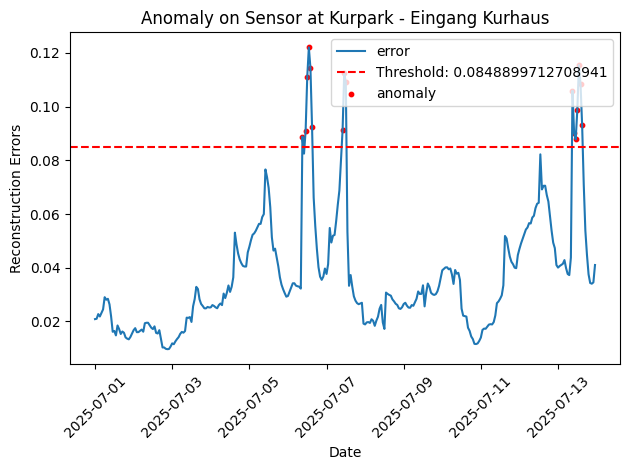

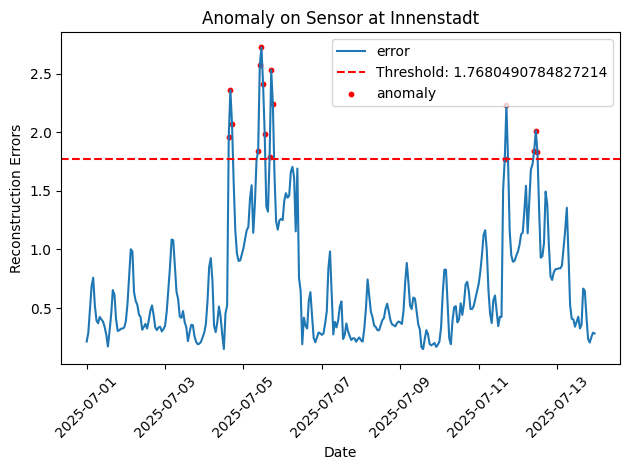

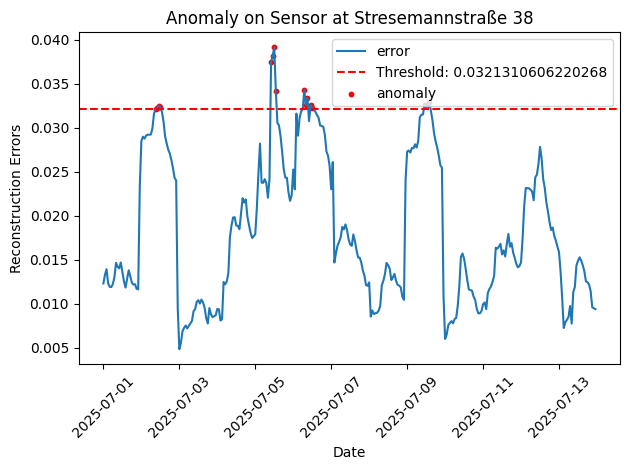

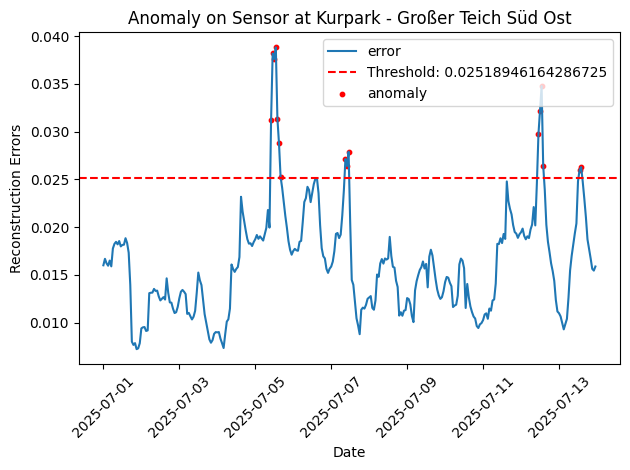

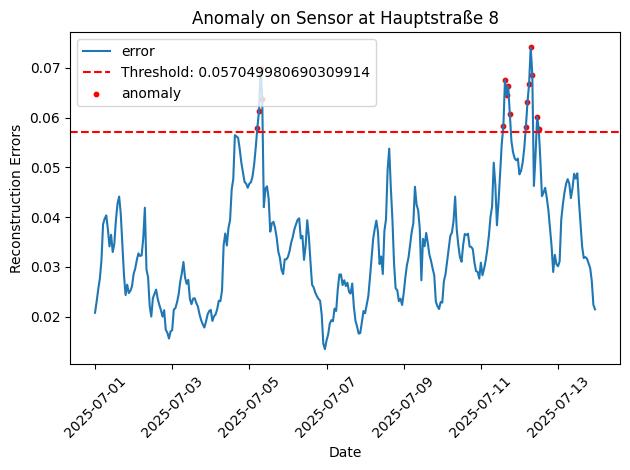

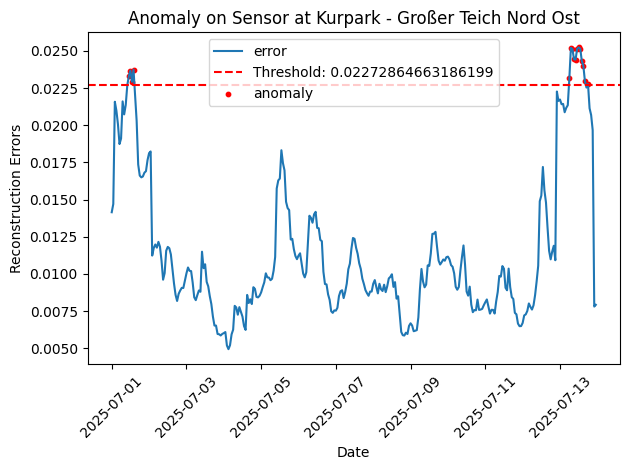

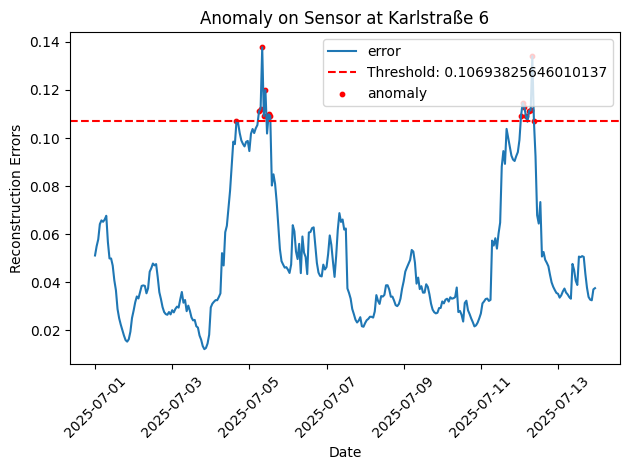

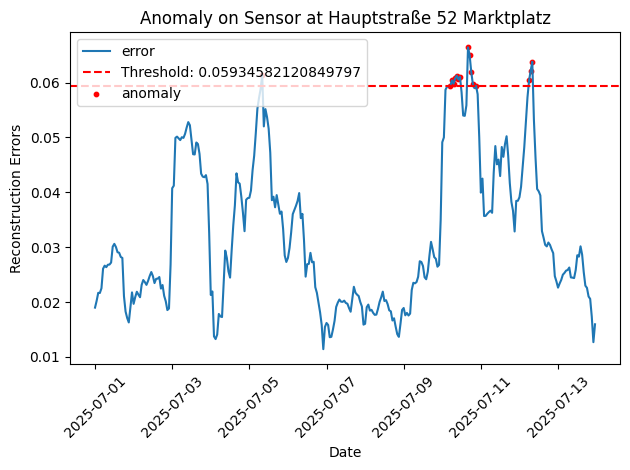

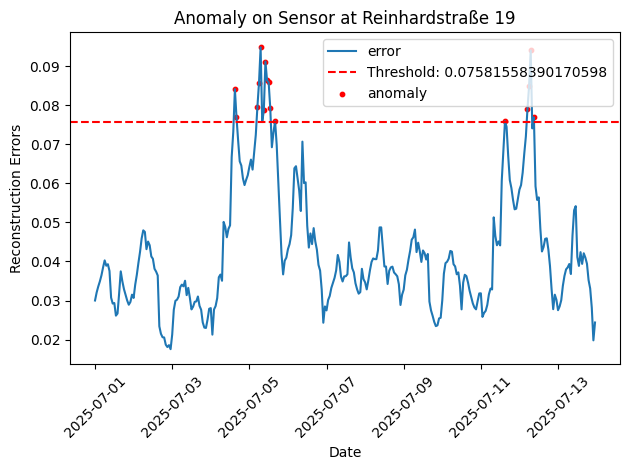

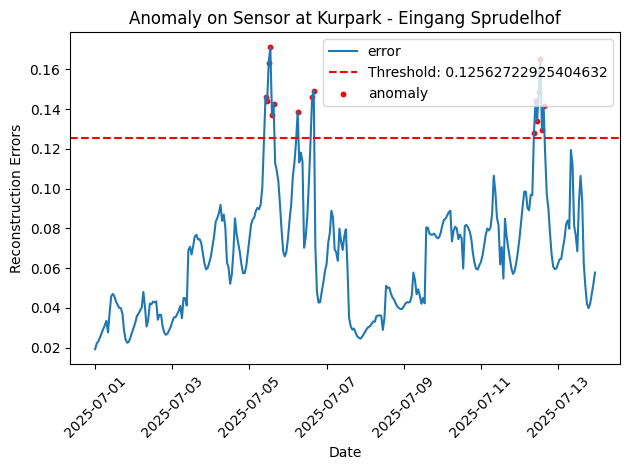

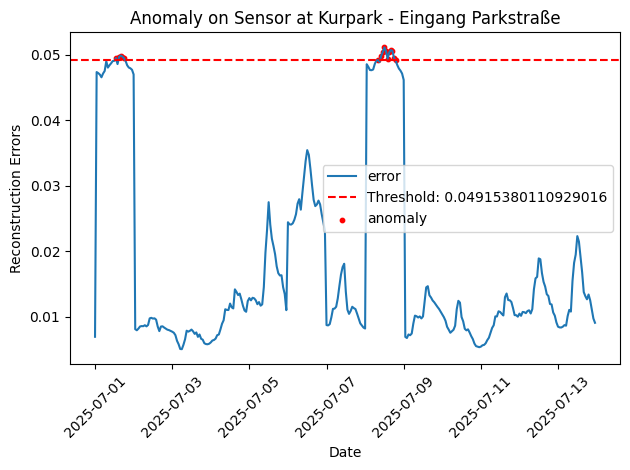

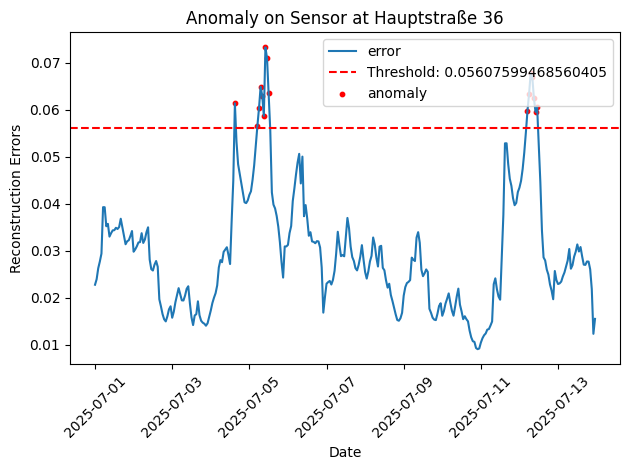

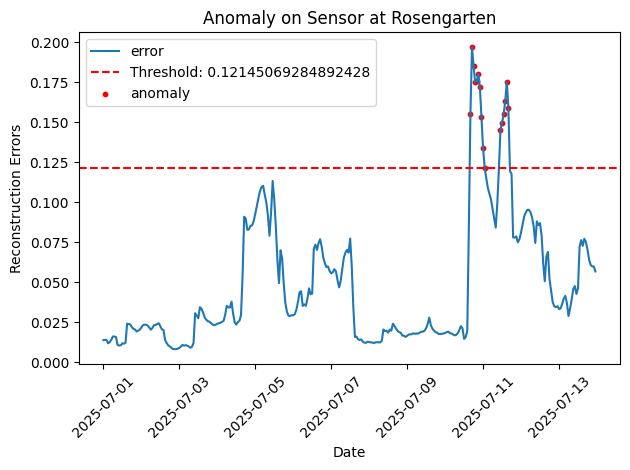

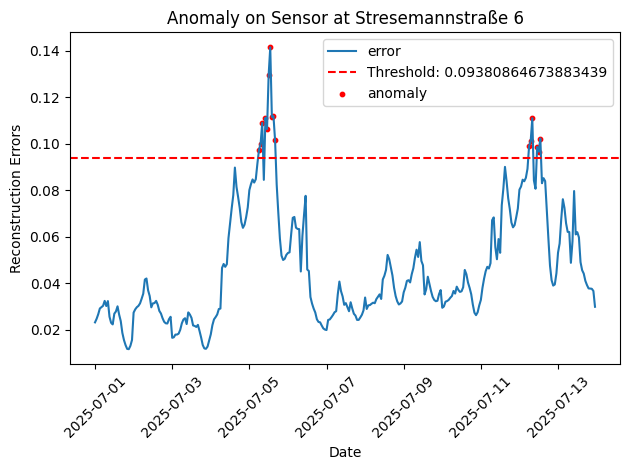

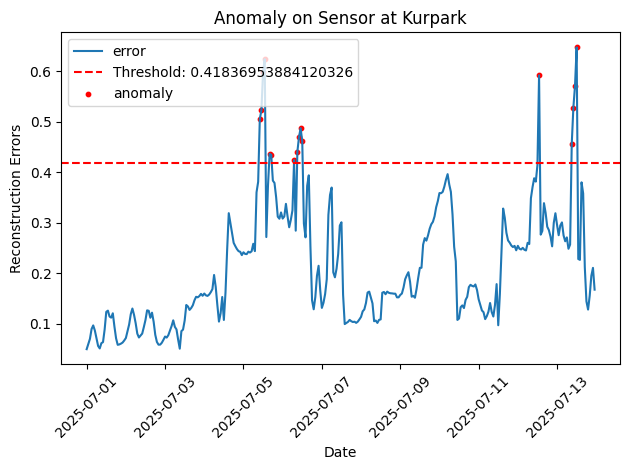

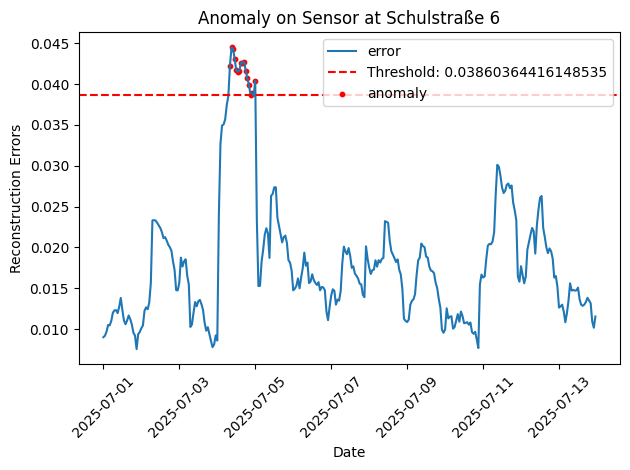

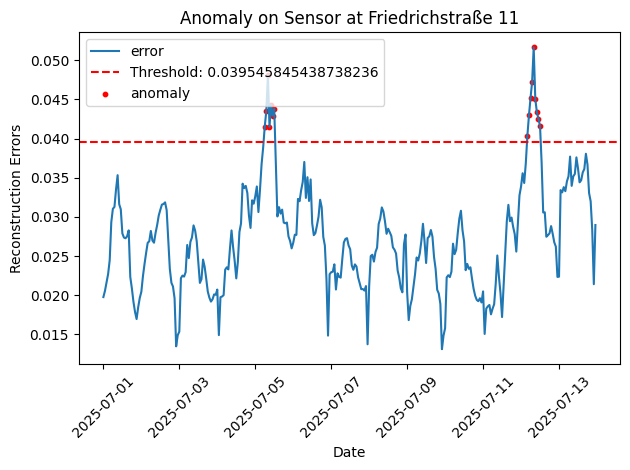

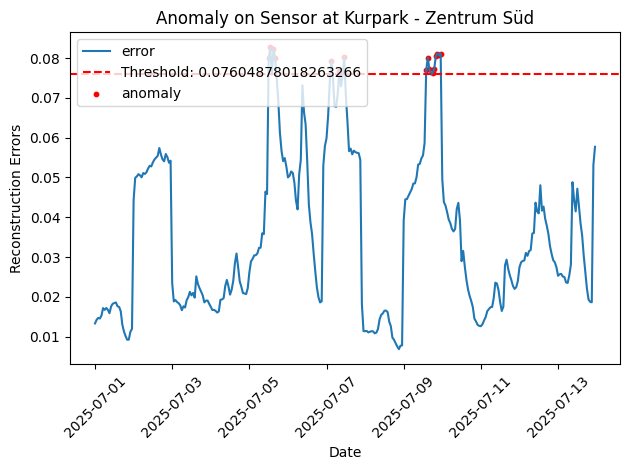

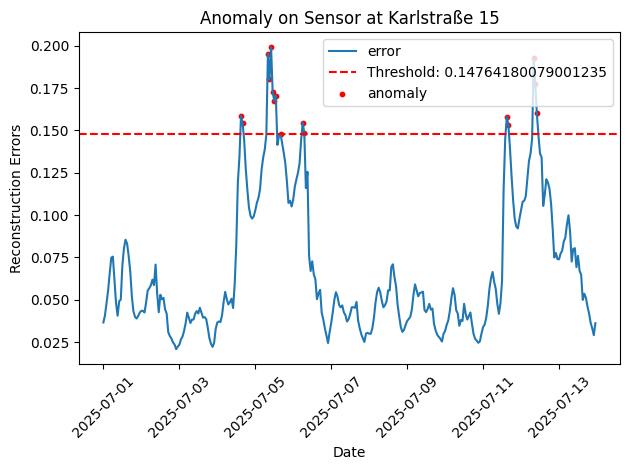

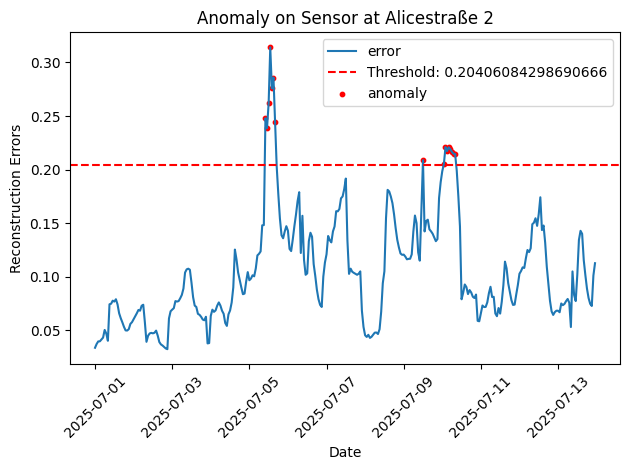

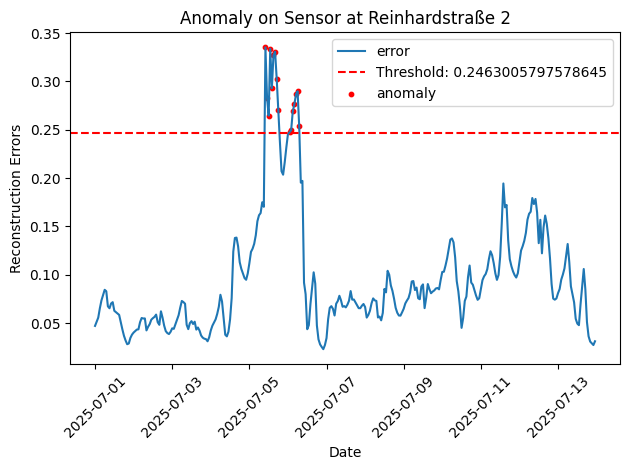

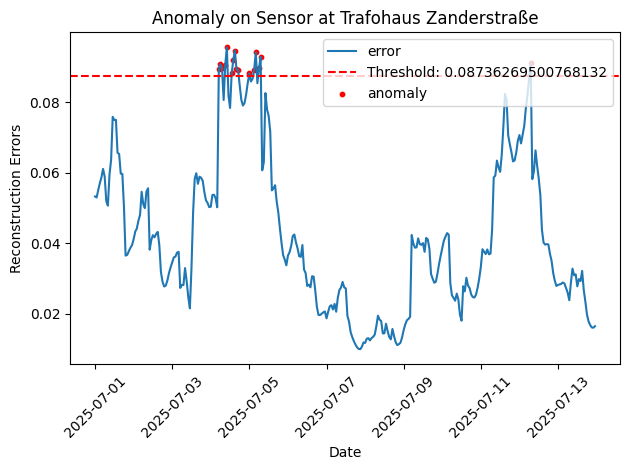

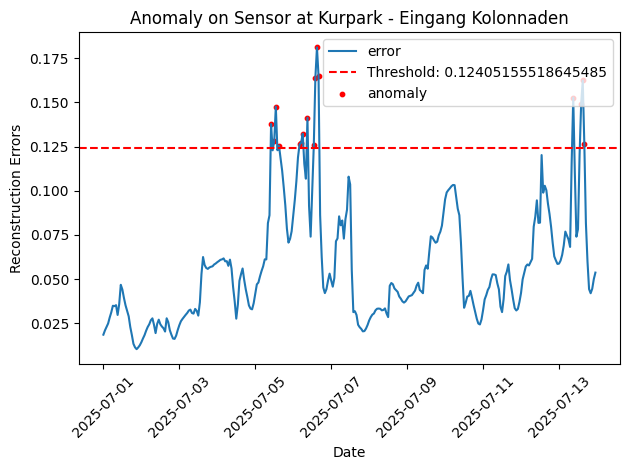

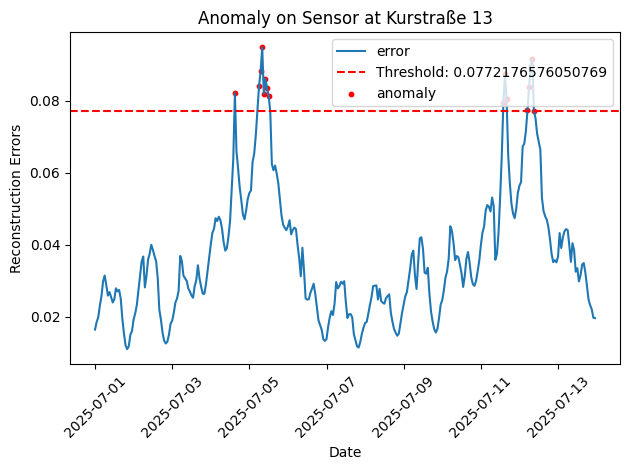

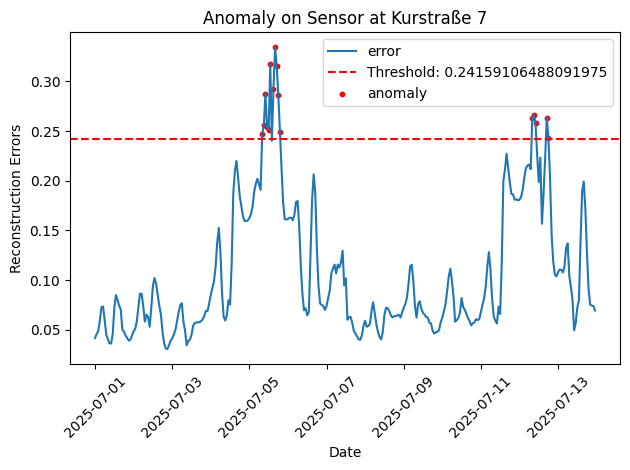

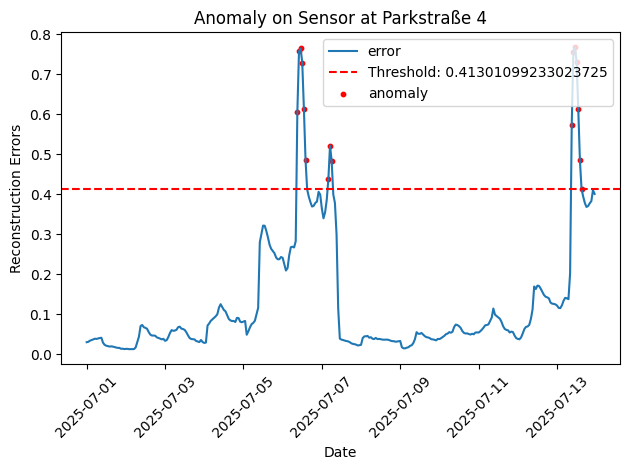

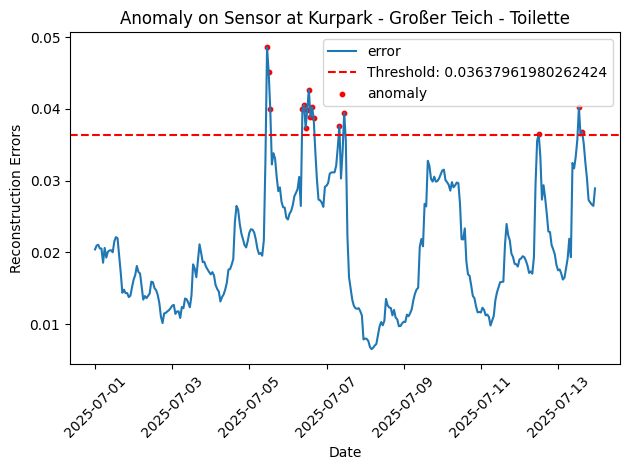

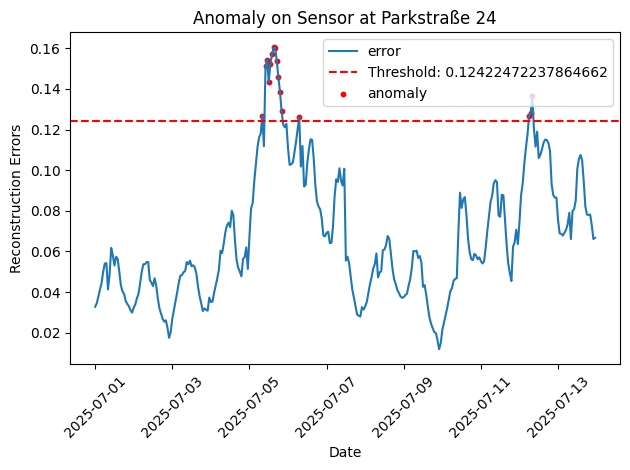

In [57]:
for sensor in sensors:
    anomaly_plot(sensor)

In [58]:
def prepare_anamoly_report(sensor_id:str):
    directory = Path('anomaly_report')
    directory.mkdir(parents = True, exist_ok=True)
    
    sensor_data = results[results['SID'] == sensor_id]
    location = sensor_data['location'].iloc[0]
    sensor_data = sensor_data.groupby('timestamp',as_index=False)['error'].mean()
    threshold = np.percentile(sensor_data['error'],95)
    sensor_data['anomaly'] = np.where(
        sensor_data["error"] > threshold,
        "Yes",
        "No")

    output_file = directory/f"{location}.csv"
    sensor_data.to_csv(output_file)

In [59]:
for sensor in sensors:
    prepare_anamoly_report(sensor)

In [60]:
data[data['name'] == 'Innenstadt'].iloc[225]['visitors']

np.float64(467.0)

In [34]:
#Save model for further use
model.save('global_model.keras')